In [13]:
from starit import starit, save_image, get_bounding_box
import pandas as pd
import os
import numpy as np
from PIL import Image

# Interpreting STARIT rasterization intensities

In [21]:
# Manually make two dataframes of molecules (one gene)
cell1_data = pd.DataFrame({
    "x_position": [0, 50, 100, 150, 200, 0, 50, 100, 150, 200],
    "y_position": [10, 0, 20, 10, 10, 0, 0, 0, 20, 20],
})

cell2_data = pd.DataFrame({
    "x_position": [95, 105, 90, 100, 110, 95, 105, 90, 100, 110],
    "y_position": [10, 0, 10, 20, 0, 0, 20, 10, 20, 10],
})


In [22]:
print(f"cell1_data shape: {cell1_data.shape}")  
print(f"cell2_data shape: {cell2_data.shape}")  

cell1_data shape: (10, 2)
cell2_data shape: (10, 2)


In [23]:
# Set output folder
output_dir = "data/simulation_jean"
os.makedirs(output_dir, exist_ok=True)

In [24]:
# Combine for bounding box calculation
all_x = pd.concat([cell1_data["x_position"], cell2_data["x_position"]])
all_y = pd.concat([cell1_data["y_position"], cell2_data["y_position"]])
bounding_box = get_bounding_box(all_x, all_y, expand=2)


0 of 10
9 of 10
0 of 10
9 of 10


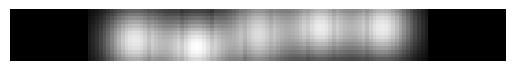

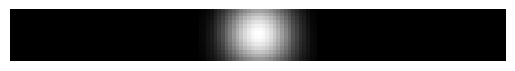

In [25]:
# Process cell1
results1 = starit(
    bounding_box,
    cell1_data["x_position"],
    cell1_data["y_position"],
    g=np.ones(1),
    dx=3.0,
    blur=3.0,
    draw=10000,
    wavelet_magnitude=False,
    use_windowing=True
)
save_image(results1[3], f"{output_dir}/cell1_starit_result.png")

# Process cell2
results2 = starit(
    bounding_box,
    cell2_data["x_position"],
    cell2_data["y_position"],
    g=np.ones(1),
    dx=3.0,
    blur=3.0,
    draw=10000,
    wavelet_magnitude=False,
    use_windowing=True
)
save_image(results2[3], f"{output_dir}/cell2_starit_result.png")

In [26]:
# Read the image
path1 = f"{output_dir}/cell1_starit_result.png"
img = Image.open(path1)

# Convert to numpy array and calculate intensity metrics
img_array = np.array(img)
sum_intensity = img_array.sum()
max_intensity = img_array.max()

print(f"Mean intensity: {sum_intensity}")
print(f"Max intensity: {max_intensity}")

# Read the image
path1 = f"{output_dir}/cell2_starit_result.png"
img = Image.open(path1)

# Convert to numpy array and calculate intensity metrics
img_array = np.array(img)
sum_intensity = img_array.sum()
max_intensity = img_array.max()

print(f"Mean intensity: {sum_intensity}")
print(f"Max intensity: {max_intensity}")


Mean intensity: 14264535
Max intensity: 255
Mean intensity: 8352504
Max intensity: 255


Even though both cells have 10 counts of this gene, the rasterized STARIT representations have a sum intensity that is larger for the cell with more subcellularly spatially distributed molecular organization and smaller for the cell with more punctated molecular organization.